# 0. Setup

In [1]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
import pathlib as Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system
os.chdir('..')                          # changes to the parent directory

# tools for text processing
from tools import text_tools

In [2]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['mountains_of_madness.txt', 'nyarlathotep.txt', 'moon_bog.txt', 'book.txt', 'other_gods.txt', 'randolph_carter.txt', 'picture_house.txt', 'cool_air.txt', 'alchemist.txt', 'nameless.txt', 'festival.txt', 'reanimator.txt', 'arthur_jermyn.txt', 'dunwich.txt', 'doorstep.txt', 'ulthar.txt', 'haunter.txt', 'crawling_chaos.txt', 'from_beyond.txt', 'dagon.txt', 'pharoahs.txt', 'juan_romero.txt', 'colour_out_of_space.txt', 'clergyman.txt', 'celephais.txt', 'iranon.txt', 'poetry_of_gods.txt', 'descendent.txt', 'shunned_house.txt', 'beyond_wall_of_sleep.txt', 'redhook.txt', 'outsider.txt', 'dreams_in_the_witch.txt', 'charles_dexter_ward.txt', 'pickman.txt', 'old_folk.txt', 'he.txt', 'memory.txt', 'martins_beach.txt', 'polaris.txt', 'hypnos.txt', 'ex_oblivione.txt', 'medusas_coil.txt', 'street.txt', 'erich_zann.txt', 'rats_walls.txt', 'kadath.txt', 'tree.txt', 'innsmouth.txt', 'gates_of_silver_key.txt', 'azathoth.txt', 'white_ship.txt', 'terrible_old_man.txt', 'high_house_mist.txt', 'silver_key.t

In [10]:
entities_list = [
    'Azathoth',
    'Nyarlathotep',
    'Yog-Sothoth',
    'Shub-Niggurath',
    'Cthulhu',
    'Dagon',
    'Yig',
    'Tsathoggua',
    'Old Ones',
    'Deep Ones',
    'Shoggoth',
    'Shoggoths',
    'Mi-Go',
    'night-gaunt',
    'night-gaunts'
    # "Cor (Colour) do Espaço" # pensar no que fazer com esse
]

artefacts = [
    "Necronomicon",
    "Shining Trapezohedron"
]

places = [
    "R’lyeh",
    "Leng",
    "Yuggoth"
]

In [12]:
entities_df = pd.DataFrame() # creates an empty DataFrame to store entities
entities_df['name'] = entities_list

# verifying quantity of texts in which each entity appears
entities_df['number_of_texts'] = [ 
    sum([text_tools.search_name('data/silver/texts/'+file, entity) for file in biblio.files]) 
    for entity in entities_list ]

entities_df

,name,number_of_texts
0,Azathoth,5
1,Nyarlathotep,7
2,Yog-Sothoth,5
3,Shub-Niggurath,5
4,Cthulhu,7
5,Dagon,2
6,Yig,1
7,Tsathoggua,4
8,Old Ones,6
9,Deep Ones,1


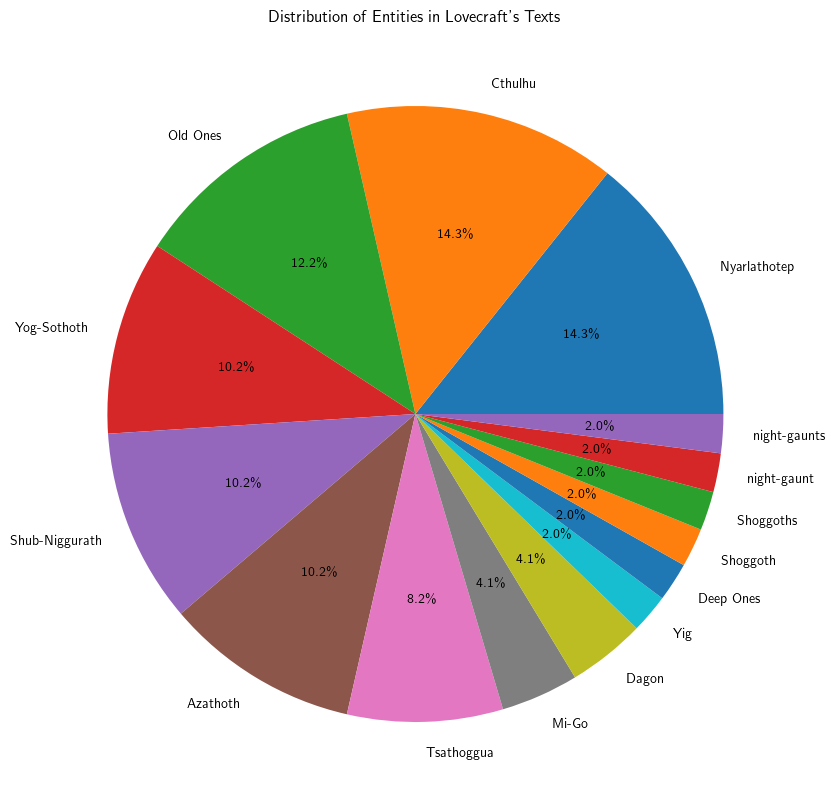

In [24]:
# plotting a pie chart of the distribution of entities in the texts
plt.figure(figsize=(10,10)) # sets the figure size

# organizing by highest number of appearances
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)

# plotting the absolute values, not the percentages, to avoid the problem of small percentages being invisible in the pie chart
plt.pie(entities_df['number_of_texts'], labels=entities_df['name'], autopct='%1.1f%%') # creates a pie chart with labels and percentages
plt.title('Distribution of Entities in Lovecraft\'s Texts') # sets the title of the plot
plt.show() # displays the plot


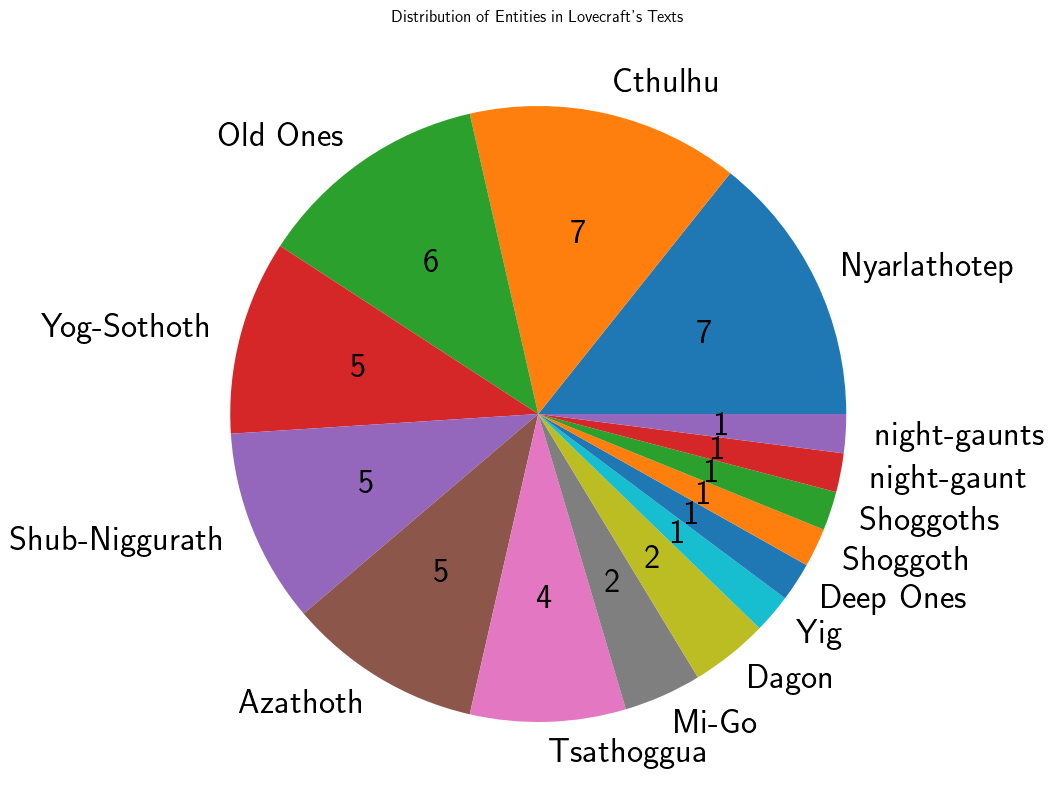

In [34]:
# plotting a pie chart of the distribution of entities in the texts
fig, ax = plt.subplots(figsize=(10,10)) # sets the figure size

# organizing by highest number of appearances
entities_df = entities_df.sort_values(by='number_of_texts', ascending=False)

# plotting the absolute values in each slice label instead of percentages
total = entities_df['number_of_texts'].sum()
wedges, texts, autotexts = ax.pie(
    entities_df['number_of_texts'],
    labels=entities_df['name'],
    autopct=lambda pct: str(int(round(pct * total / 100))),
    textprops={'fontsize': 25}
)

# custom legend showing entity names and counts with a larger font size
legend_labels = [f"{name}: {count}" for name, count in zip(entities_df['name'], entities_df['number_of_texts'])]


ax.set_title('Distribution of Entities in Lovecraft\'s Texts') # sets the title of the plot
plt.setp(autotexts, size=25, weight='bold')
plt.show() # displays the plot
